## B . Dask ML : Iris Classification

-> **Data:** iris.cv
-> **Expected Results:**
    
    - Dask pipeline for data preprocessing
    
    - Adapting code for Random Forest Classifier and Gradient Boost Tree Classifier

    - Performance Comparaison

In [1]:
#%pip install --upgrade dask numpy scikit-learn
#%pip install --upgrade distributed numba
!pip list | grep -E "dask|numpy|scikit-learn|distributed|numba"

dask                      2025.2.0
dask-glm                  0.3.2
dask_labextension         7.0.0
dask-ml                   2025.1.0
distributed               2025.2.0
numba                     0.61.0
numpy                     2.1.3
scikit-learn              1.6.1


In [2]:
import os
import time
import matplotlib.pyplot as plt
import dask.dataframe as dd
from dask_ml.preprocessing import StandardScaler, LabelEncoder
from dask_ml.model_selection import train_test_split
from dask_ml.compose import ColumnTransformer
from sklearn.pipeline import Pipeline  
from dask_ml.metrics import accuracy_score
from dask_ml.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from sklearn.multiclass import OneVsRestClassifier  
from sklearn.tree import DecisionTreeClassifier

In [3]:
"""----------------------------------------------------------------------------
LOAD IRIS DATA
----------------------------------------------------------------------------"""
data_dir = "./data"
file = os.path.join(data_dir, "iris.csv")

# Load Data
iris_df = dd.read_csv(file)

# Checking the data was correctly loaded
print("Schema:")
print(iris_df.dtypes)
print("Sample data:")
print(iris_df.head(5))

Schema:
sepal_length            float64
sepal_width             float64
petal_length            float64
petal_width             float64
variety         string[pyarrow]
dtype: object
Sample data:
   sepal_length  sepal_width  petal_length  petal_width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa


       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


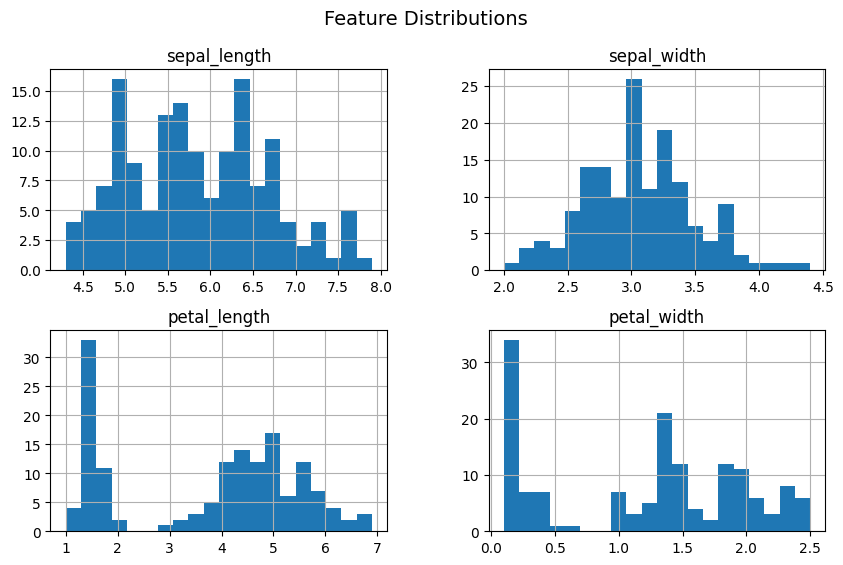

variety
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64[pyarrow]


In [4]:
"""--------------------------------------------------------------------------
Perform Data Analytics
-------------------------------------------------------------------------"""

# Summary Statistics
print(iris_df.describe().compute())

# Convert to Pandas for visualization
pandas_df = iris_df.compute()

# Plot histograms for each feature
pandas_df.hist(figsize=(10, 6), bins=20)
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()

# Checking class distributions
print(pandas_df["variety"].value_counts())

In [5]:
"""----------------------------------------------------------------------------
CREATING THE PIPELINE
----------------------------------------------------------------------------"""

# Convert categorical target column into numerical values
label_encoder = LabelEncoder()

# Assemble feature columns into a single feature vector
feature_columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Scale features
scaler = StandardScaler()

# Train-Test Split
train_df, test_df = train_test_split(iris_df, test_size=0.2, random_state=42, shuffle=True)

In [6]:
def make_predictions_using_pipeline(model):
    # Build the pipeline
    pipeline = Pipeline([
        ('scaler', scaler),
        ('model', model)
    ])

    # Train the model
    pipeline.fit(train_df[feature_columns], train_df['variety']
                )
    # Make predictions
    predictions = pipeline.predict(test_df[feature_columns])

    y_true = test_df['variety'].compute().to_numpy()
    
    # Evaluate accuracy
    accuracy = accuracy_score(y_true, predictions)

    return accuracy

In [7]:
# Decision Tree Model
dt = DecisionTreeClassifier()
accuracy = make_predictions_using_pipeline(dt)
print(f"Decision Tree Accuracy: {accuracy:.4f}")

Decision Tree Accuracy: 0.9655


In [8]:
# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=20)
accuracy = make_predictions_using_pipeline(rf)
print(f"Random Forest Accuracy: {accuracy:.4f}")

Random Forest Accuracy: 0.9655


In [9]:
# Gradient Boosted Classifier
gbt = GradientBoostingClassifier()
ovr = OneVsRestClassifier(gbt)
accuracy = make_predictions_using_pipeline(ovr)
print(f"Gradient Boosted Accuracy: {accuracy:.4f}")

Gradient Boosted Accuracy: 0.9655
